# PT3.1 - Linear Regression

**AI Bootcamp - Instinct Institute**

**Author:** MORK Mongkul

## EX1: Problem from slide

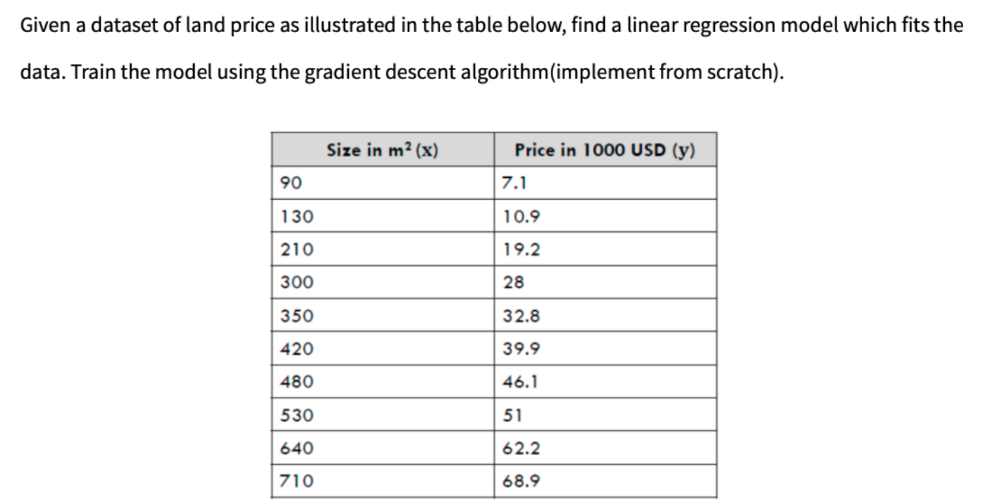

In [1]:
# data
x = [90, 130, 210, 300, 350, 420, 480, 530, 640, 710]
y = [7.1, 10.9, 19.2, 28, 32.8, 39.9, 46.1, 51, 62.2, 68.9]

In [2]:
import numpy as np 

X = np.array(x)
y = np.array(y)

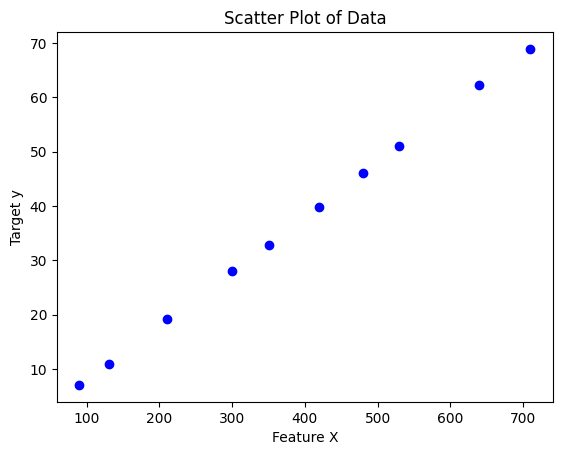

In [3]:
import matplotlib.pyplot as plt 

plt.scatter(X, y, color='blue')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.title('Scatter Plot of Data')
plt.show()

In [4]:
#hypotheis fucntion 
def hyp(x, a,b):
    y  = a*x + b
    return y

#cost function
def cost_function(y_predtict, y_actual):
    c = (y_predtict - y_actual)**2
    c = c.mean()
    return c
#gradient descent
def grad_a(x, y_predict, y_actual):
    g_a = (y_predict - y_actual)*x
    g_a = 2*g_a.mean()
    return g_a

def grad_b(y_predict, y_actual):
    g_b = (y_predict - y_actual)
    g_b = 2*g_b.mean()
    return g_b

In [5]:
#Training the model
a = 0 
b = 0
alpha = 0.000001
losses = []

for epoch in range(1, 201):
    y_predict = hyp(X, a,b)
    cost = cost_function(y_predict, y)
    losses.append(cost)

    #update parameters
    a = a - alpha*grad_a(X, y_predict, y)
    b = b - alpha*grad_b(y_predict, y)

    print(f"Epoch {epoch}: Cost={cost:.4f}, a={a:.4f}, b={b:.4f}")

Epoch 1: Cost=1733.1970, a=0.0361, b=0.0001
Epoch 2: Cost=674.0767, a=0.0586, b=0.0001
Epoch 3: Cost=262.4754, a=0.0727, b=0.0001
Epoch 4: Cost=102.5167, a=0.0814, b=0.0002
Epoch 5: Cost=40.3526, a=0.0869, b=0.0002
Epoch 6: Cost=16.1940, a=0.0903, b=0.0002
Epoch 7: Cost=6.8054, a=0.0924, b=0.0002
Epoch 8: Cost=3.1568, a=0.0937, b=0.0002
Epoch 9: Cost=1.7388, a=0.0946, b=0.0002
Epoch 10: Cost=1.1877, a=0.0951, b=0.0002
Epoch 11: Cost=0.9736, a=0.0954, b=0.0002
Epoch 12: Cost=0.8903, a=0.0956, b=0.0002
Epoch 13: Cost=0.8580, a=0.0957, b=0.0002
Epoch 14: Cost=0.8454, a=0.0958, b=0.0002
Epoch 15: Cost=0.8405, a=0.0958, b=0.0002
Epoch 16: Cost=0.8387, a=0.0959, b=0.0002
Epoch 17: Cost=0.8379, a=0.0959, b=0.0002
Epoch 18: Cost=0.8376, a=0.0959, b=0.0002
Epoch 19: Cost=0.8375, a=0.0959, b=0.0002
Epoch 20: Cost=0.8375, a=0.0959, b=0.0002
Epoch 21: Cost=0.8375, a=0.0959, b=0.0002
Epoch 22: Cost=0.8374, a=0.0959, b=0.0002
Epoch 23: Cost=0.8374, a=0.0959, b=0.0002
Epoch 24: Cost=0.8374, a=0.0959,

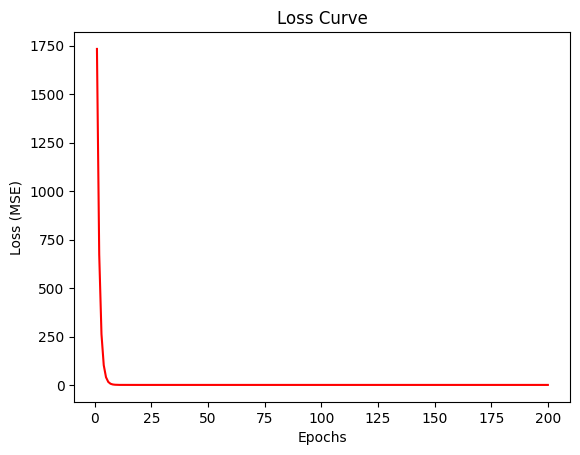

In [6]:
plt.plot(range(1, 201), losses, color='red')
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.show()

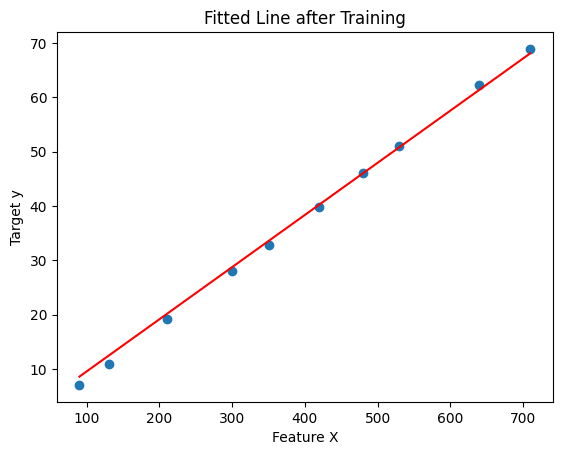

In [7]:
#fitted line
plt.scatter(x,y)
plt.plot(x, hyp(X, a,b), color='red')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.title('Fitted Line after Training')
plt.show()

## Scikit-Learn

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
model = LinearRegression()
model.fit(X.reshape(-1, 1), y)

LinearRegression()

In [10]:
y_pred = model.predict(X.reshape(-1, 1))

In [11]:
print(f" Slop a : {model.coef_[0]:.4f}, Intercept b : {model.intercept_:.4f}")

 Slop a : 0.1000, Intercept b : -1.9825


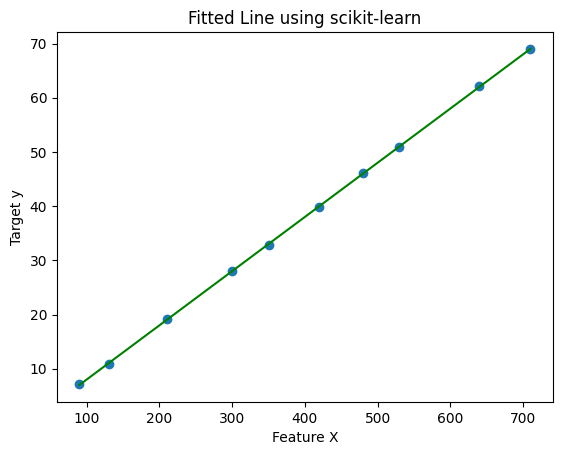

In [12]:
#plot 
plt.scatter(x,y)
plt.plot(x, y_pred, color='green')
plt.xlabel('Feature X')
plt.ylabel('Target y')
plt.title('Fitted Line using scikit-learn')
plt.show()

# Exercise 1

Build a linear regression which predicts the land price using both the `land_area` and the `distance_to_city` features. (See the dataset in `land_price_1.csv`)

In [13]:
# To Do 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [18]:
df = pd.read_csv('https://raw.githubusercontent.com/MorkMongkul/AI-Bootcamp-Instinct/main/Data/land_price_1%20.csv')
df.head()

,land_area,dist_to_city,price
0,122,12.9,15.7
1,173,18.4,11.3
2,341,11.0,42.0
3,439,19.3,35.0
4,477,19.7,37.7


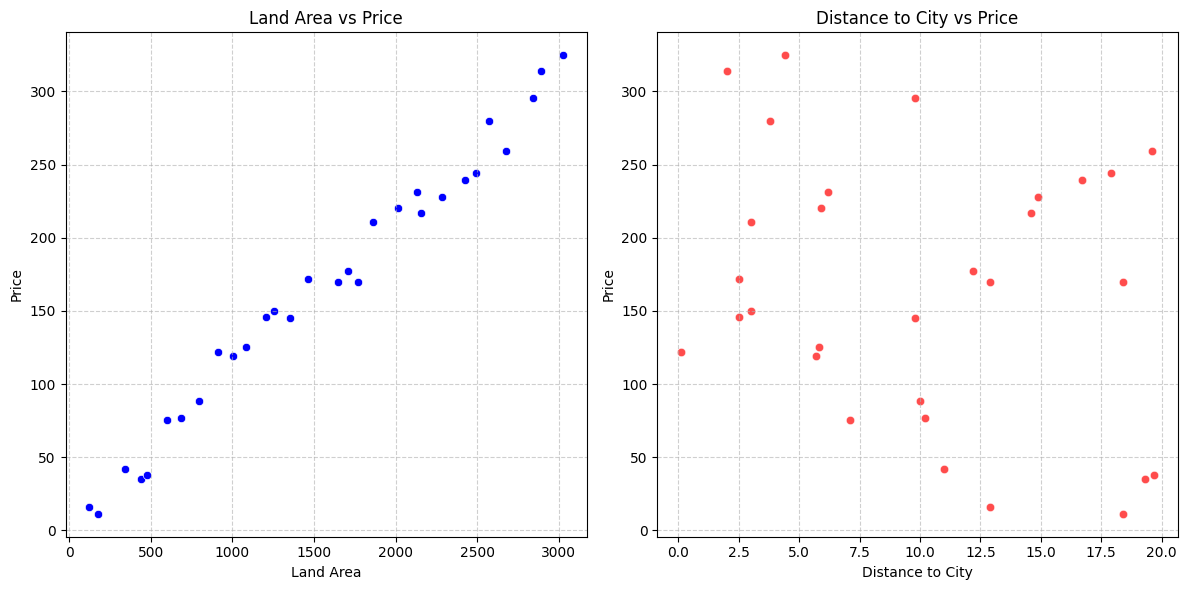

In [19]:
fig , axes = plt.subplots(1,2, figsize=(12,6))

#1.Land area
sns.scatterplot(ax=axes[0], data = df, x = 'land_area' , y = 'price' , color = 'blue')
axes[0].set_title('Land Area vs Price')
axes[0].set_xlabel('Land Area')
axes[0].set_ylabel('Price')
axes[0].grid(True, linestyle='--', alpha=0.6)

#2. distance to city
sns.scatterplot(ax=axes[1], data=df, x='dist_to_city', y='price', color='red', alpha=0.7)
axes[1].set_title('Distance to City vs Price')
axes[1].set_xlabel('Distance to City')
axes[1].set_ylabel('Price')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

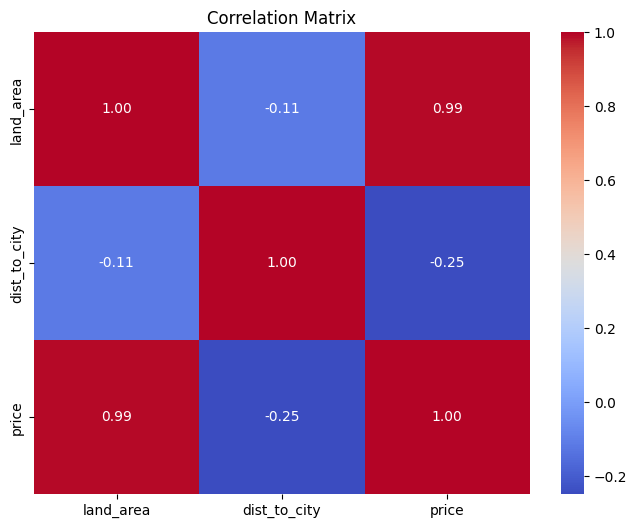

In [20]:
#correlation matrix 
plt.clf()
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [34]:
x1_raw = df['land_area']
x2_raw = df['dist_to_city']

x1_mean, x1_std = x1_raw.mean(), x1_raw.std()
x2_mean, x2_std = x2_raw.mean(), x2_raw.std()

x1 = (x1_raw - x1_mean) / x1_std
x2 = (x2_raw - x2_mean) / x2_std

In [35]:
x1.shape, x2.shape

((30,), (30,))

# Linear Regression Model(Maths Intuition)

Let the training dataset be:  
$$
\{(x_1^{(i)}, x_2^{(i)}, y^{(i)})\}_{i=1}^{n}
$$

**Hypothesis (Prediction):**  
$$
\hat{y}^{(i)} = w_1 x_1^{(i)} + w_2 x_2^{(i)} + b
$$
$$
\hat{\mathbf{y}} = w_1 \mathbf{x}_1 + w_2 \mathbf{x}_2 + b
$$

**Cost Function (Mean Squared Error):**  
$$
J(w_1, w_2, b) = \frac{1}{n} \sum_{i=1}^{n} (\hat{y}^{(i)} - y^{(i)})^2
$$

**Gradients:**  
$$
\frac{\partial J}{\partial w_1} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}^{(i)} - y^{(i)}) x_1^{(i)}
$$
$$
\frac{\partial J}{\partial w_2} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}^{(i)} - y^{(i)}) x_2^{(i)}
$$
$$
\frac{\partial J}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} (\hat{y}^{(i)} - y^{(i)})
$$


In [36]:
#hypothesis function
def hyp(w1, w2, b, x1, x2):
    return (w1 * x1) + (w2 * x2) + b

def cost_function(y_pred, y_actual):
    # Mean Squared Error
    return np.mean((y_pred - y_actual)**2)

# Gradients
def grad_w1(x1, y_pred, y_actual):
    return 2 * np.mean((y_pred - y_actual) * x1)

def grad_w2(x2, y_pred, y_actual):
    return 2 * np.mean((y_pred - y_actual) * x2)

def grad_b(y_pred, y_actual):
    return 2 * np.mean(y_pred - y_actual)

In [37]:
#Initialize variables
w1, w2, b = 0, 0, 0
learning_rate = 0.001
epochs = 5000
losses = []

#Training Loop
for epoch in range(epochs):
    # Calculate prediction
    y_pred = hyp(w1, w2, b, x1, x2)
    
    # Calculate cost
    cost = cost_function(y_pred, df['price'])
    losses.append(cost)

    if epoch % 500 == 0:
    
        print(f"Epoch {epoch}: Cost={cost:.4f}, w1={w1:.4f}, w2={w2:.4f}, b={b:.4f}")
    
    # Calculate gradients
    gw1 = grad_w1(x1, y_pred, df['price'])
    gw2 = grad_w2(x2, y_pred, df['price'])
    gb = grad_b(y_pred, df['price'])

    # Update parameters
    w1 -= learning_rate * gw1
    w2 -= learning_rate * gw2
    b  -= learning_rate * gb

print(f"\nFinal Result: y = ({w1:.4f})x1 + ({w2:.4f})x2 + {b:.4f}")

Epoch 0: Cost=35052.9207, w1=0.0000, w2=0.0000, b=0.0000
Epoch 500: Cost=4740.2702, w1=54.9967, w2=-11.3810, b=104.2046
Epoch 1000: Cost=648.3090, w1=75.5440, w2=-13.4207, b=142.5010
Epoch 1500: Cost=90.0563, w1=83.3136, w2=-13.3369, b=156.5754
Epoch 2000: Cost=12.9613, w1=86.2875, w2=-12.9783, b=161.7478
Epoch 2500: Cost=2.1632, w1=87.4395, w2=-12.7162, b=163.6488
Epoch 3000: Cost=0.6262, w1=87.8909, w2=-12.5676, b=164.3474
Epoch 3500: Cost=0.4033, w1=88.0697, w2=-12.4919, b=164.6041
Epoch 4000: Cost=0.3704, w1=88.1413, w2=-12.4554, b=164.6985
Epoch 4500: Cost=0.3654, w1=88.1702, w2=-12.4384, b=164.7332

Final Result: y = (88.1819)x1 + (-12.4307)x2 + 164.7459


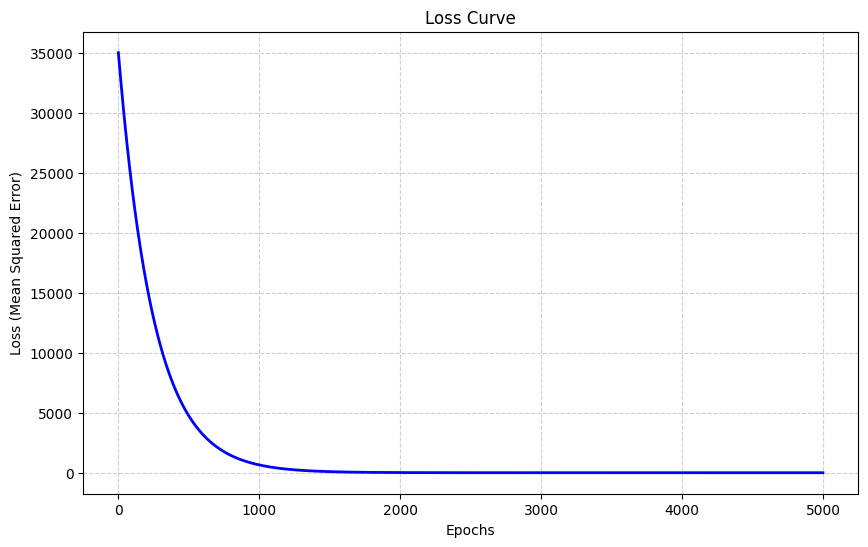

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(losses, color='blue', linewidth=2)
plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [39]:
import plotly.graph_objects as go

# Scatter points (actual data)
scatter = go.Scatter3d(
    x=x1,
    y=x2,
    z=y,
    mode='markers',
    marker=dict(
        size=5,
        color='blue',
        opacity=0.8
    ),
    name='Actual Data'
)

# Grid for plane
x1_grid, x2_grid = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 30),
    np.linspace(x2.min(), x2.max(), 30)
)

y_pred_grid = w1 * x1_grid + w2 * x2_grid + b

# Regression plane
plane = go.Surface(
    x=x1_grid,
    y=x2_grid,
    z=y_pred_grid,
    opacity=0.5,
    showscale=False,
    name='Regression Plane'
)

# Figure
fig = go.Figure(data=[scatter, plane])

fig.update_layout(
    title='Multiple variable Linear Regression(Price Prediction)',
    scene=dict(
        xaxis_title='x1 (Land Area)',
        yaxis_title='x2 (Distance to City)',
        zaxis_title='Price'
    ),
    width=800,
    height=600
)

fig.show()


In [40]:
#Evaluate the model
Mean_Squared_Error = cost_function(hyp(w1, w2, b, x1, x2), df['price'])
print(f"Mean Squared Error on Training Data: {Mean_Squared_Error:.4f}")

Mean Squared Error on Training Data: 0.3646


In [41]:
R2_score = 1 - (Mean_Squared_Error / np.var(df['price']))
print(f"R² Score on Training Data: {R2_score:.4f}")

R² Score on Training Data: 1.0000


## Scikit-Learn 


In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [43]:
X = df[['land_area', 'dist_to_city']]
y = df['price']

In [44]:
X_scaled = StandardScaler().fit_transform(X)
X_scaled.shape

(30, 2)

In [45]:
model = LinearRegression()
model.fit(X_scaled, y)

LinearRegression()

In [46]:
print(f" Coefficients : {model.coef_}, Intercept : {model.intercept_:.4f}")

 Coefficients : [ 86.70784549 -12.21575569], Intercept : 164.7533


In [47]:
# Scatter points (actual data)
scatter = go.Scatter3d(
    x=x1,
    y=x2,
    z=y,
    mode='markers',
    marker=dict(
        size=5,
        color='blue',
        opacity=0.8
    ),
    name='Actual Data'
)

# Grid for plane
x1_grid, x2_grid = np.meshgrid(
    np.linspace(x1.min(), x1.max(), 30),
    np.linspace(x2.min(), x2.max(), 30)
)

y_pred_grid = w1 * x1_grid + w2 * x2_grid + b

# Regression plane
plane = go.Surface(
    x=x1_grid,
    y=x2_grid,
    z=y_pred_grid,
    opacity=0.5,
    showscale=False,
    name='Regression Plane'
)

# Figure
fig = go.Figure(data=[scatter, plane])

fig.update_layout(
    title='Multiple variable Linear Regression(Price Prediction)',
    scene=dict(
        xaxis_title='x1 (Land Area)',
        yaxis_title='x2 (Distance to City)',
        zaxis_title='Price'
    ),
    width=800,
    height=600
)

fig.show()


# Exercise 2

Using only the distance feature, build a model with hypothesis $h(x) = \theta_{0}+\theta_{1}x+\theta_{3}\sqrt{x}$ to predict the `land_price`. (See the dataset in `land_price_2.csv`.)


In [48]:
#To Do
df = pd.read_csv('https://raw.githubusercontent.com/MorkMongkul/AI-Bootcamp-Instinct/main/Data/land_price_2.csv')
df.head()

,land_area,price
0,129,140.9
1,214,200.3
2,343,280.4
3,387,298.8
4,454,358.2


In [ ]:
x = df['land_area'].values
y = df['price'].values

x1 = x
x2 = np.sqrt(x)


In [49]:
#apply feature scaling
x1 = (x1 - x1.mean()) / x1.std()
x2 = (x2 - x2.mean()) / x2.std()

In [50]:
#hypothesis function
def hyp(w1, w2, b, x1, x2):
    return (w1 * x1) + (w2 * x2) + b

def cost_function(y_pred, y_actual):
    # Mean Squared Error
    return np.mean((y_pred - y_actual)**2)

# Gradients
def grad_w1(x1, y_pred, y_actual):
    return 2 * np.mean((y_pred - y_actual) * x1)

def grad_w2(x2, y_pred, y_actual):
    return 2 * np.mean((y_pred - y_actual) * x2)

def grad_b(y_pred, y_actual):
    return 2 * np.mean(y_pred - y_actual)

In [51]:
#Initialize variables
w1, w2, b = 0, 0, 0
learning_rate = 0.1
epochs = 10000
losses = []

#Training Loop
for epoch in range(epochs):
    # Calculate prediction
    y_pred = hyp(w1, w2, b, x1, x2)
    
    # Calculate cost
    cost = cost_function(y_pred, y)
    losses.append(cost)

    if epoch % 500 == 0:
    
        print(f"Epoch {epoch}: Cost={cost:.4f}, w1={w1:.4f}, w2={w2:.4f}, b={b:.4f}")
    
    # Calculate gradients
    gw1 = grad_w1(x1, y_pred, y)
    gw2 = grad_w2(x2, y_pred, y)
    gb = grad_b(y_pred, y)

    # Update parameters
    w1 -= learning_rate * gw1
    w2 -= learning_rate * gw2
    b  -= learning_rate * gb

print(f"\nFinal Result: y = ({w1:.4f})x1 + ({w2:.4f})x2 + {b:.4f}")

Epoch 0: Cost=35052.9207, w1=0.0000, w2=0.0000, b=0.0000
Epoch 500: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 1000: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 1500: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 2000: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 2500: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 3000: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 3500: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 4000: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 4500: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 5000: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 5500: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 6000: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 6500: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 7000: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 7500: Cost=0.3645, w1=88.1901, w2=-12.4246, b=164.7533
Epoch 8000: Cost=0.3645, w1=8

## Scikit-Learn 

In [52]:
x = df['land_area'].values
y = df['price'].values

In [53]:
X = np.column_stack([
    x,              # x
    np.sqrt(x)      # sqrt(x)
])
X

array([[ 129.        ,   11.35781669],
       [ 214.        ,   14.62873884],
       [ 343.        ,   18.52025918],
       [ 387.        ,   19.67231557],
       [ 454.        ,   21.30727575],
       [ 565.        ,   23.76972865],
       [ 675.        ,   25.98076211],
       [ 798.        ,   28.24889378],
       [ 879.        ,   29.64793416],
       [1016.        ,   31.8747549 ],
       [1095.        ,   33.09078422],
       [1222.        ,   34.95711659],
       [1272.        ,   35.665109  ],
       [1429.        ,   37.80211634],
       [1467.        ,   38.301436  ],
       [1593.        ,   39.91240409],
       [1661.        ,   40.75536774],
       [1773.        ,   42.10700654],
       [1946.        ,   44.11349   ],
       [2046.        ,   45.23273151],
       [2115.        ,   45.98912915],
       [2235.        ,   47.27578661],
       [2337.        ,   48.34252786],
       [2391.        ,   48.89785271],
       [2516.        ,   50.15974482],
       [2564.        ,   

In [54]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-1.64114232, -2.11050412],
       [-1.54285417, -1.84509844],
       [-1.39368744, -1.52933684],
       [-1.34280887, -1.43585791],
       [-1.26533468, -1.30319571],
       [-1.13698192, -1.10338998],
       [-1.00978549, -0.92398466],
       [-0.86755675, -0.73994633],
       [-0.77389392, -0.62642689],
       [-0.61547655, -0.44574057],
       [-0.52412639, -0.34707082],
       [-0.37727232, -0.19563486],
       [-0.31945576, -0.1381877 ],
       [-0.13791177,  0.03521108],
       [-0.09397118,  0.07572634],
       [ 0.05172655,  0.2064418 ],
       [ 0.13035707,  0.27484066],
       [ 0.25986616,  0.38451389],
       [ 0.45991146,  0.54732184],
       [ 0.57554458,  0.63813814],
       [ 0.65533143,  0.69951295],
       [ 0.79409117,  0.80391354],
       [ 0.91203696,  0.89046993],
       [ 0.97447884,  0.9355295 ],
       [ 1.11902024,  1.03792061],
       [ 1.17452414,  1.0765608 ],
       [ 1.29593891,  1.15984465],
       [ 1.42544801,  1.24689444],
       [ 1.53414314,

In [55]:
model = LinearRegression()
model.fit(X_scaled, y)

w_1, w_3 = model.coef_
w_0 = model.intercept_

print("w0:", w_0)
print("w1:", w_1)
print("w3:", w_3)

w0: 977.6533333333332
w1: 440.0736584265021
w3: 54.57128825308084


# Exercise 3: Mini Project 01

With your team, collect your own dataset which consists at least two features and one target variable.

Build a linear regression model to predict the target variable. Split your dataset into training set (80%) and testing set (20%).


In [ ]:
#To Do